In [1]:
import sys
sys.path.append('/workspace')
sys.path.append('/workspace/src')
import os
# change the current working directory to the workspace
os.chdir('/workspace')
from tqdm import tqdm
import pandas as pd

from src.models.config import Config
from src.supervised_runner import SupervisedRunner
from src.semi_supervised_runner import SemiSupervisedRunner
from src.self_supervised_runner import SelfSupervisedRunner

In [19]:
def load_model(train_type, run_folder_path, load_dataloaders=False):
    if not os.path.exists(os.path.join(run_folder_path, 'config.txt')):
        raise FileNotFoundError(f"Config file not found at {os.path.join(run_folder_path, 'config.txt')}")
    config = Config.from_txt(os.path.join(run_folder_path, 'config.txt'))
    if train_type == 'supervised':
        runner = SupervisedRunner(config, 'single')
    elif train_type == 'semi_supervised':
        runner = SemiSupervisedRunner(config, 'single')
    elif train_type == 'self_supervised':
        runner = SelfSupervisedRunner(config, 'single')
    else:
        raise ValueError(f"Invalid train type: {train_type}")
    model = runner.load_model_from_checkpoint(os.path.join(run_folder_path, 'checkpoints', 'best_model.ckpt'))

    if load_dataloaders:
        if runner._type() == 'supervised':
            labeled_dataloader,_,_= runner.load_dataloaders(runner.labeled_data_df, pd.DataFrame(), pd.DataFrame(), runner.unlabeled_data_df)
            return model, labeled_dataloader
        else:
            labeled_dataloader,_,_,unlabeled_dataloader= runner.load_dataloaders(runner.labeled_data_df, pd.DataFrame(), pd.DataFrame(), runner.unlabeled_data_df)
            return model, (labeled_dataloader, unlabeled_dataloader)
    else:
        return model

In [20]:

TRAIN_TYPE = 'self_supervised'
TRAIN_METHOD = 'simclr'
FEATURE_EXTRACTOR = 'resnet18'
RUN_FOLDER_NAME = '20260420_084233'

run_folder_path = '/workspace/runs/single/' + TRAIN_TYPE + '/' + TRAIN_METHOD + '/' + FEATURE_EXTRACTOR + '/' + RUN_FOLDER_NAME
model, (labeled_dataloader, unlabeled_dataloader) = load_model(TRAIN_TYPE, run_folder_path, load_dataloaders=True)
simclr_feature_extractor = model.feature_extractor
print(f"{TRAIN_TYPE} {TRAIN_METHOD} {FEATURE_EXTRACTOR} feature extractor loaded: ", simclr_feature_extractor)

Seed set to 44


Random seeds set to 44 for reproducibility
Blocks to freeze: [Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64,

In [ ]:
TRAIN_TYPE = 'supervised'
TRAIN_METHOD = ''
FEATURE_EXTRACTOR = 'resnet18'
RUN_FOLDER_NAME = '20260420_145343'

run_folder_path = '/workspace/runs/cross_validate/' + TRAIN_TYPE + '/' + TRAIN_METHOD + '/' + FEATURE_EXTRACTOR + '/' + RUN_FOLDER_NAME
model = load_model(TRAIN_TYPE, run_folder_path)
supervised_feature_extractor = model.feature_extractor
print(f"{TRAIN_TYPE} {TRAIN_METHOD} {FEATURE_EXTRACTOR} feature extractor loaded: ", supervised_feature_extractor)


Seed set to 44


Random seeds set to 44 for reproducibility
Blocks to freeze: [Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64,

In [5]:
TRAIN_TYPE = 'supervised'
TRAIN_METHOD = ''
FEATURE_EXTRACTOR = 'resnet18'
RUN_FOLDER_NAME = '20260420_151658'

run_folder_path = '/workspace/runs/single/' + TRAIN_TYPE + '/' + TRAIN_METHOD + '/' + FEATURE_EXTRACTOR + '/' + RUN_FOLDER_NAME
model = load_model(TRAIN_TYPE, run_folder_path)
supervised_feature_extractor2 = model.feature_extractor
print(f"{TRAIN_TYPE} {TRAIN_METHOD} {FEATURE_EXTRACTOR} feature extractor loaded: ", supervised_feature_extractor2)


Seed set to 44


Random seeds set to 44 for reproducibility
Blocks to freeze: [Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64,

In [6]:
def extract_features(feature_extractor, dataloader):
    original_extracted_features = []
    augmentations_extracted_features = []
    original_labels = []
    augmentations_labels = []
    device = next(feature_extractor.parameters()).device
    for (_image_path, is_transformed, normalized_transformed_image_tensor, _extra_features, label) in tqdm(dataloader, desc="Extracting features"):
        features = feature_extractor(normalized_transformed_image_tensor.to(device))
        for i in range(len(is_transformed)):
            if is_transformed[i]:
                augmentations_extracted_features.append(features[i].detach().cpu().numpy())
                augmentations_labels.append(label[i].cpu().numpy().item())
            else:
                original_extracted_features.append(features[i].detach().cpu().numpy())
                original_labels.append(label[i].cpu().numpy().item())
    return original_extracted_features, augmentations_extracted_features, original_labels, augmentations_labels

In [7]:
simclr_original_extracted_features, simclr_augmentations_extracted_features, simclr_original_labels, simclr_augmentations_labels = extract_features(simclr_feature_extractor, labeled_dataloader)
print(f"Extracted features for {len(simclr_original_extracted_features)} original images each with {len(simclr_original_extracted_features[0])} features")
print(f"Extracted features for {len(simclr_augmentations_extracted_features)} augmented images each with {len(simclr_augmentations_extracted_features[0])} features")



Extracting features: 100%|██████████| 74/74 [00:10<00:00,  6.95it/s]

Extracted features for 589 original images each with 64 features
Extracted features for 1767 augmented images each with 64 features


In [8]:
supervised_original_extracted_features, supervised_augmentations_extracted_features, supervised_original_labels, supervised_augmentations_labels = extract_features(supervised_feature_extractor, labeled_dataloader)
print(f"Extracted features for {len(supervised_original_extracted_features)} original images each with {len(supervised_original_extracted_features[0])} features")
print(f"Extracted features for {len(supervised_augmentations_extracted_features)} augmented images each with {len(supervised_augmentations_extracted_features[0])} features")


Extracting features: 100%|██████████| 74/74 [00:11<00:00,  6.51it/s]

Extracted features for 589 original images each with 64 features
Extracted features for 1767 augmented images each with 64 features


In [14]:
supervised_original_extracted_features2, supervised_augmentations_extracted_features2, supervised_original_labels2, supervised_augmentations_labels2 = extract_features(supervised_feature_extractor2, labeled_dataloader)
print(f"Extracted features for {len(supervised_original_extracted_features2)} original images each with {len(supervised_original_extracted_features2[0])} features")
print(f"Extracted features for {len(supervised_augmentations_extracted_features2)} augmented images each with {len(supervised_augmentations_extracted_features2[0])} features")


Extracting features: 100%|██████████| 74/74 [00:10<00:00,  6.81it/s]

Extracted features for 589 original images each with 64 features
Extracted features for 1767 augmented images each with 64 features


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_feature_space(X, y, id_to_name, rng):
    # Matrix of backbone features and integer labels (same order)
    n = len(y)

    # Scale so PCA / t-SNE are not dominated by a few dimensions
    X_scaled = StandardScaler().fit_transform(X)

    # Linear 2D view (fast, interpretable variance axes)
    pca = PCA(n_components=2, random_state=rng)
    X_pca = pca.fit_transform(X_scaled)

    # Nonlinear 2D view (often better for class separation at low D)
    perp = min(30, max(5, (n - 1) // 3))
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=1000,
        random_state=rng,
    )
    X_tsne = tsne.fit_transform(X_scaled)

    unique_ids = np.unique(y)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    for ax, Z, title in zip(
        axes,
        (X_pca, X_tsne),
        (
            f"PCA (var explained: {pca.explained_variance_ratio_.sum():.1%})",
            f"t-SNE (perplexity={perp})",
        ),
    ):
        for lid in unique_ids:
            m = y == lid
            name = id_to_name.get(int(lid), f"class_{int(lid)}")
            ax.scatter(Z[m, 0], Z[m, 1], s=10, alpha=0.75, label=name)
        ax.set_title(title)
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.grid(True, alpha=0.25)

    handles, labels_leg = axes[0].get_legend_handles_labels()
    # Single shared legend
    fig.legend(handles, labels_leg, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
    plt.suptitle(f"Labeled feature embeddings (n={n}, dim={X.shape[1]})", y=1.02)
    plt.tight_layout()
    plt.show()

In [10]:
config = Config.from_txt(os.path.join(run_folder_path, 'config.txt'))
id_to_name = {int(k): str(v) for k, v in config.label_to_name.items()}

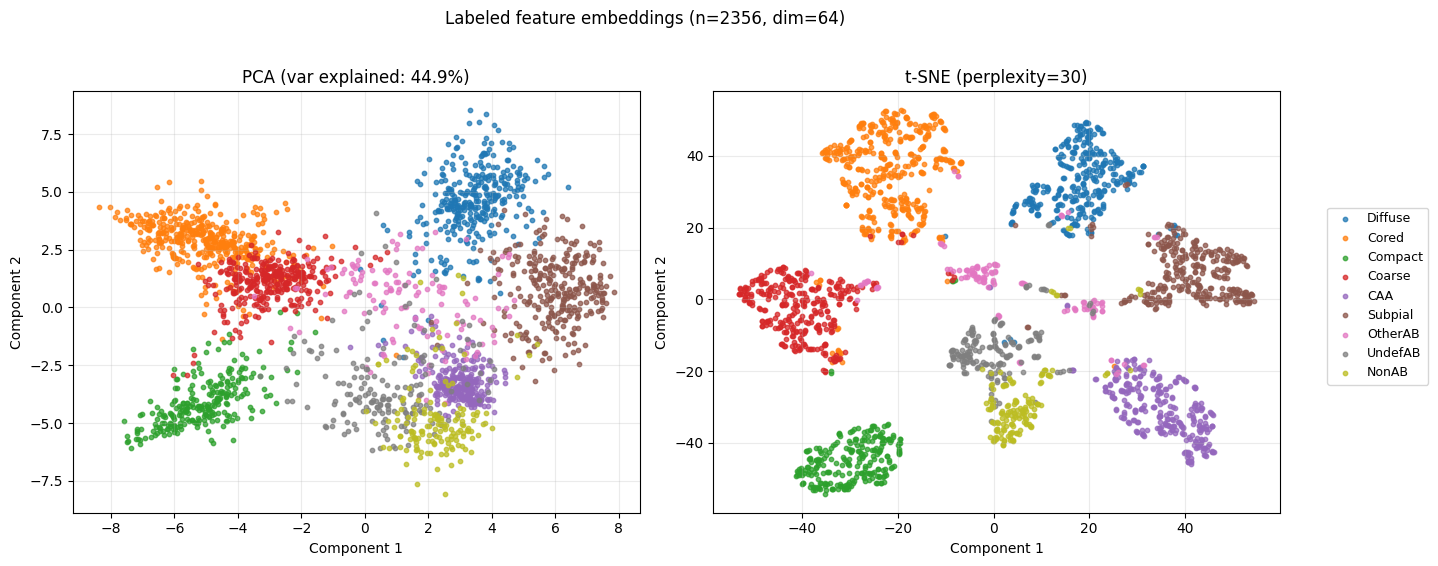

In [11]:
X = np.stack(simclr_original_extracted_features+simclr_augmentations_extracted_features, axis=0)
y = np.array(simclr_original_labels+simclr_augmentations_labels, dtype=np.int64)
visualize_feature_space(X, y, id_to_name, config.general_config.system.random_seed)


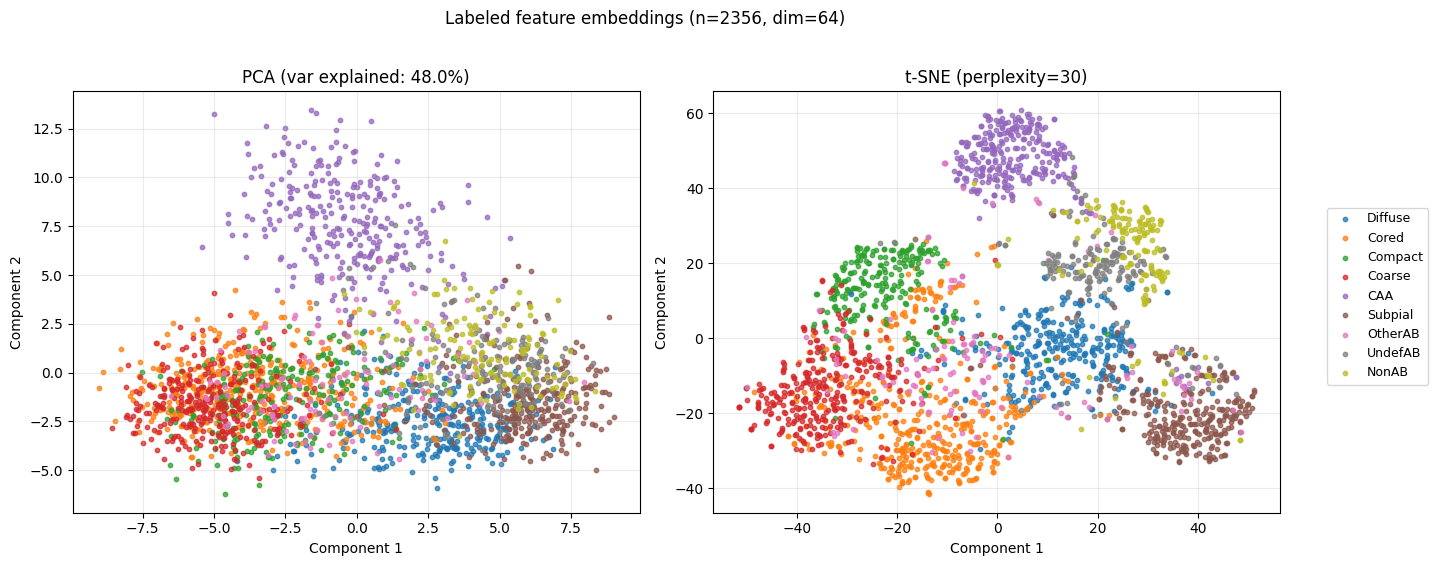

In [12]:
X = np.stack(supervised_original_extracted_features+supervised_augmentations_extracted_features, axis=0)
y = np.array(supervised_original_labels+supervised_augmentations_labels, dtype=np.int64)
visualize_feature_space(X, y, id_to_name, config.general_config.system.random_seed)

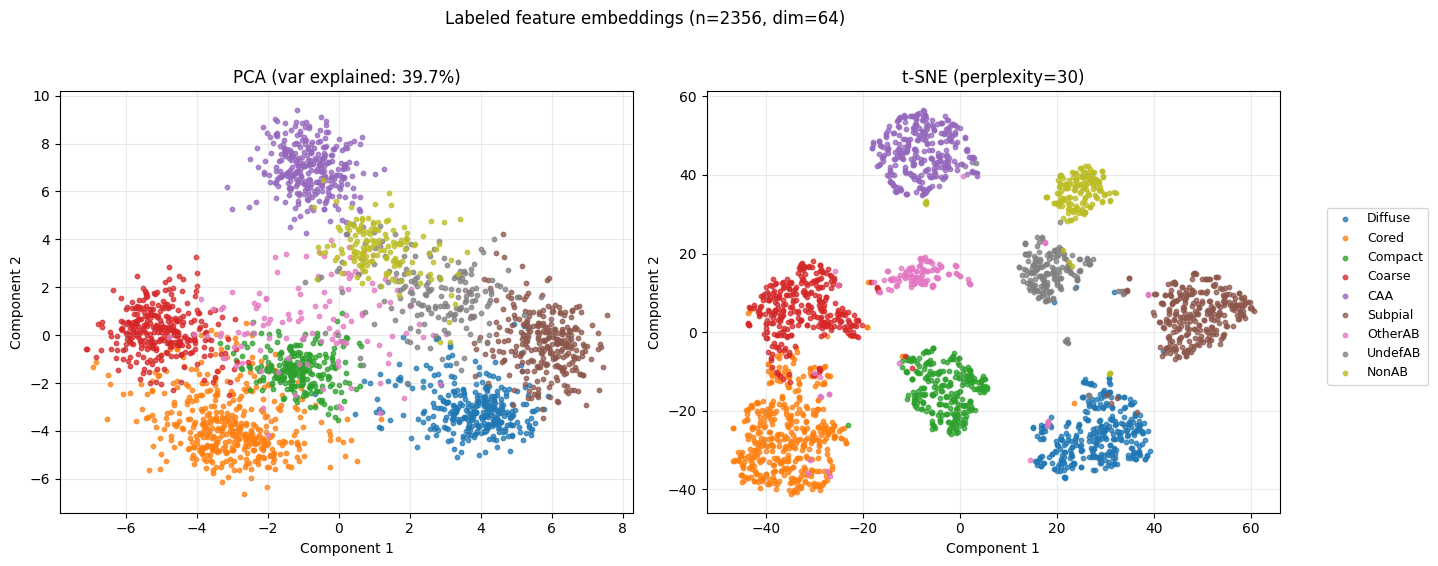

In [15]:
X = np.stack(supervised_original_extracted_features2+supervised_augmentations_extracted_features2, axis=0)
y = np.array(supervised_original_labels2+supervised_augmentations_labels2, dtype=np.int64)
visualize_feature_space(X, y, id_to_name, config.general_config.system.random_seed)